In [41]:
import numpy as np
import pyvista as pv
import os

# ─────────────────────────────────────────────────────────────────────────────
# 1. Load eigendata
# ─────────────────────────────────────────────────────────────────────────────
Mesh = 55222
Re   = 60
Mach = 0.2
gamma = 1.4
R_gas = 287.0          # confirm units match the solver

nev = 10
ncv = 300
SIGMA = "R+50"

eigen_dir = "/home/ahf25/git/flux_jacobian/data/eigendata/v3_mesh"
# eigen_dir = "C:/Users/User/Git/flux_jacobian/data/eigendata/sigma_sweep/nev10_ncv600"
# eigen_file = f"eigendata_{Mesh}_Re{Re}_M{Mach}_nev{nev}_ncv{ncv}_sig{SIGMA}.npz"
eigen_file = f"eigendata_{Mesh}_Re{Re}_M{Mach}_nev{nev}_ncv{ncv}_np15.npz"
data = np.load(f"{eigen_dir}/{eigen_file}")

eigenvalues  = data['eigenvalues']      # (nconv,)   complex
eigenvectors = data['eigenvectors']     # (nconv, N) complex  N = 5*n_nodes
residuals    = data['residuals']        # (nconv,)   real
sigma        = data['sigma'][0]         # complex shift used

nconv  = len(eigenvalues)
N      = eigenvectors.shape[1] // 5    # number of mesh nodes

print(f"Loaded {nconv} eigenpairs,  N nodes = {N}")
print(f"Sigma used: {sigma:.4f}")


# # sort by largest growth rate (matches report_results ordering)
# sort_idx    = np.argsort(-eigenvalues.real)
# eigenvalues  = eigenvalues[sort_idx]
# eigenvectors = eigenvectors[sort_idx]
# residuals    = residuals[sort_idx]

Loaded 91 eigenpairs,  N nodes = 55222
Sigma used: 0.0000+59.7217j


In [42]:
# show leading eigenpair without sorting
# by defauly, the leading eigenpair is the one closest to SIGMA
print(eigenvalues[0])

(4.009278327295853+55.44479194915128j)


In [43]:
# find a mode that is close to a target

def find_mode(eigenvalues, target, residuals=None, residual_tol=1e-6,
              n_candidates=5):
    """
    Find the index of the eigenvalue closest to a prescribed complex target.

    Parameters
    ----------
    eigenvalues   : (M,) complex array
    target        : complex  — e.g. -5.0 + 59.7j
    residuals     : (M,) real array or None — if provided, unreliable modes
                    are penalised (pushed to the back) before distance ranking
    residual_tol  : float — threshold above which a mode is deemed unreliable
    n_candidates  : int   — number of closest candidates to print for inspection

    Returns
    -------
    best_idx : int — index of the closest reliable mode
    """
    eigenvalues = np.asarray(eigenvalues)
    dist        = np.abs(eigenvalues - target)

    # penalise unreliable modes so they never win
    if residuals is not None:
        unreliable       = np.asarray(residuals) > residual_tol
        dist[unreliable] = np.inf

    ranked = np.argsort(dist)
    best_idx = ranked[0]

    # print top candidates for a sanity check
    print(f"Target: {target.real:.4f} + {target.imag:.4f}j\n")
    print(f"{'Rank':>5} {'Index':>7} {'Re(λ)':>14} {'Im(λ)':>14} "
          f"{'|λ−target|':>14} {'residual':>12}")
    print("-" * 70)
    for rank, idx in enumerate(ranked[:n_candidates]):
        lam = eigenvalues[idx]
        res_str = f"{residuals[idx]:.2e}" if residuals is not None else "n/a"
        marker  = " ←" if rank == 0 else ""
        print(f"{rank:>5} {idx:>7} {lam.real:>14.4f} {lam.imag:>14.4f} "
              f"{dist[idx]:>14.4f} {res_str:>12}{marker}")

    return int(best_idx)

In [44]:
target   = 11 + 55j

# only search for the first 10 modes [:10] 
best_idx = find_mode(eigenvalues, target, residuals=residuals, n_candidates=285)

lam = eigenvalues[best_idx]
vec = eigenvectors[best_idx].reshape(N, 5)

Target: 11.0000 + 55.0000j

 Rank   Index          Re(λ)          Im(λ)     |λ−target|     residual
----------------------------------------------------------------------
    0       0         4.0093        55.4448         7.0049     6.90e-07 ←
    1       6        18.9015        64.0470        12.0117     9.38e-07
    2       7        11.0285        42.5202        12.4799     8.87e-07
    3       1        10.0424        67.6285        12.6648     6.86e-07
    4       4        16.3905        67.5497        13.6585     7.82e-07
    5      11        24.0489        68.0527        18.4566     1.61e-07
    6      19        28.7541        46.3244        19.7604     9.32e-07
    7      16        18.8784        35.5589        20.9768     9.57e-07
    8      10        20.9962        73.5380        21.0613     8.06e-07
    9      21        32.1848        52.7916        21.2996     8.43e-07
   10      25        31.8406        48.0539        21.9677     9.35e-07
   11      27        31.1599       

In [45]:
# filter out modes that are closest to SIGMA

# define reference parameters for St = fL/D
D     = 1
U_inf = 68.0525

# ── distance from sigma in complex plane ──────────────────────────────────────
dist = np.abs(eigenvalues - sigma)                  # (nconv,)

# ── indices of 10 closest ────────────────────────────────────────────────────
top10_closest_idx = np.argsort(dist)[:10]

# ── extract ───────────────────────────────────────────────────────────────────
top10_eigs = eigenvalues[top10_closest_idx]         # (10,)  complex
top10_vecs = eigenvectors[top10_closest_idx, :]      # (10, 5N) complex

# ── print summary ─────────────────────────────────────────────────────────────
print(f"Sigma = {sigma}")
print(f"Reference St = {abs(sigma.imag) * D / (U_inf * 2 * np.pi):.4f}")

print(f"{'#':<4} {'Global idx':>10} {'Real':>14} {'Imag':>14} {'|σ - λ|':>12}  St = Im·D/U  Residual")
print("-" * 90)
for k, idx in enumerate(top10_closest_idx):
    lam = eigenvalues[idx]
    d   = dist[idx]
    St  = abs(lam.imag) * D / (U_inf * 2 * np.pi)
    res = residuals[idx]
    print(f"{k:<4} {idx:>10} {lam.real:>14.4f} {lam.imag:>14.4f} {d:>12.4f}  {St:>4.4f} {res:>14.4e}")

Sigma = 59.72167634474197j
Reference St = 0.1397
#    Global idx           Real           Imag      |σ - λ|  St = Im·D/U  Residual
------------------------------------------------------------------------------------------
0             0         4.0093        55.4448       5.8623  0.1297     6.9002e-07
1             1        10.0424        67.6285      12.7816  0.1582     6.8611e-07
2             2        14.1925        58.4911      14.2458  0.1368     1.0740e-06
3             3        12.7027        50.3475      15.7872  0.1177     1.1727e-06
4             4        16.3905        67.5497      18.1639  0.1580     7.8233e-07
5             5        17.3310        53.2313      18.5064  0.1245     1.5251e-06
6             6        18.9015        64.0470      19.3901  0.1498     9.3823e-07
7             7        11.0285        42.5202      20.4333  0.0994     8.8661e-07
8             8        18.4483        46.4957      22.6995  0.1087     2.5031e-06
9             9        18.3594        76

In [46]:
# load plt file

from pyau3d.utils import PltFileUtils, UnkFileUtils
from pyau3d.pv.loader.au3d import arrays2vtk

# Read neccessary files

# dir = f"C:/Users/User/Git/flux_jacobian/cases/cylinder_{Mesh}_Re{Re}_M{Mach}"
dir = f"/home/ahf25/CFD_2d_cylinder_all/Steady/Ma{Mach}/v3_mesh/2d_cylinder_{Mesh}_Re{Re}"
pltfile = PltFileUtils(f"{dir}/cylinder.plt")
rstfile = UnkFileUtils(f"{dir}/cylinder.rst", extend=False)

# transform PLT file to VTK 
mesh = arrays2vtk(pltfile)

# extract the grid from the pv object and wrap it by pv.wrap
domain = pv.wrap(mesh.GetBlock(0))    # "Domain 1"  →  pv.MultiBlock
block  = pv.wrap(domain.GetBlock(0))  # "Volume"    →  pv.UnstructuredGrid

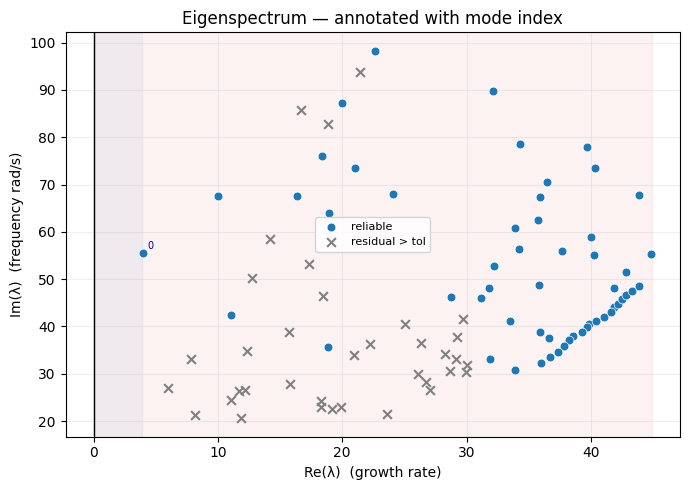

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Quick eigenspectrum overview (matplotlib)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

residual_tol = 1e-6
reliable = residuals <= residual_tol

fig, ax = plt.subplots(figsize=(7, 5))
ax.axvline(0, color='black', lw=1.0)
ax.axvspan(eigenvalues.real.min() - 0.1, 0, color='tab:blue', alpha=0.06)
ax.axvspan(0, eigenvalues.real.max() + 0.1, color='tab:red',  alpha=0.06)
ax.scatter(eigenvalues.real[reliable],  eigenvalues.imag[reliable],
           c='tab:blue', s=40, edgecolor='white', lw=0.5,
           label='reliable', zorder=3)
ax.scatter(eigenvalues.real[~reliable], eigenvalues.imag[~reliable],
           c='gray', s=40, marker='x', label='residual > tol', zorder=3)

# annotate mode indices near the imaginary axis
for i, (lam, rel) in enumerate(zip(eigenvalues, reliable)):
    if rel and abs(lam.real) < 5.0:
        ax.annotate(str(i), (lam.real, lam.imag),
                    fontsize=7, color='navy',
                    xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Re(λ)  (growth rate)');  ax.set_ylabel('Im(λ)  (frequency rad/s)')
ax.set_title('Eigenspectrum — annotated with mode index');  ax.legend(fontsize=8)
ax.grid(alpha=0.2);  plt.tight_layout();  plt.show()

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Select mode and DOF to visualise
# ─────────────────────────────────────────────────────────────────────────────
MODE_IDX = 0     # 0 = largest growth rate; change to inspect other modes
COMPONENT = 'rhou'  # 'rho' | 'rhou' | 'rhov' | 'rhow' | 'rhoE' | 'mag'
PART      = 'real' # 'real' | 'imag' | 'abs'

dof_map   = {'rho': 0, 'rhou': 1, 'rhov': 2, 'rhow': 3, 'rhoE': 4}

lam = eigenvalues[MODE_IDX]
res = residuals[MODE_IDX]
vec = eigenvectors[MODE_IDX].reshape(N, 5)   # (N, 5) complex

print(f"\nMode {MODE_IDX}:  λ = {lam.real:.6f} + {lam.imag:.6f}j   residual = {res:.2e}")
print(f"Status: {'UNSTABLE' if lam.real > 0 else 'stable'}  "
      f"{'[UNRELIABLE — residual above tol]' if res > residual_tol else ''}")


Mode 0:  λ = 4.009278 + 55.444792j   residual = 6.90e-07
Status: UNSTABLE  


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Extract scalar field from eigenvector
# ─────────────────────────────────────────────────────────────────────────────
if COMPONENT == 'mag':
    # L2 norm over all 5 DOFs per node
    field_complex = np.linalg.norm(vec, axis=1)          # real by definition
else:
    field_complex = vec[:, dof_map[COMPONENT]]

if PART == 'real':
    field = field_complex.real
elif PART == 'imag':
    field = field_complex.imag
else:                        # 'abs'
    field = np.abs(field_complex)

# normalise to [-1, 1] (eigenvectors have arbitrary amplitude)
max_abs = np.max(np.abs(field))
if max_abs > 0:
    field = field / max_abs

In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Attach to mesh and plot
# ─────────────────────────────────────────────────────────────────────────────
scalar_name = f'mode{MODE_IDX}_{COMPONENT}_{PART}'
block.point_data[scalar_name] = field

def print_mode_pick(point):
    pid  = block.find_closest_point(point)
    val  = block.point_data[scalar_name][pid]
    xy   = block.points[pid, :2]
    print(f"Node {pid:5d}  x={xy[0]:+.4f}  y={xy[1]:+.4f}  "
          f"{COMPONENT}_{PART} = {val:.4f}")

pl = pv.Plotter(notebook=True)
pl.add_mesh(block,
            scalars=scalar_name,
            cmap='RdBu',               # red = +, blue = −
            clim=[-1,1],              # symmetric around 0
            show_edges=False,
            edge_color='grey',
            opacity=0.95,
            pickable=True,
            show_scalar_bar=False)

pl.add_scalar_bar(
    title=f'Mode {MODE_IDX}  λ={lam.real:.4f}+{lam.imag:.4f}j\n'
          f'{COMPONENT} ({PART}, normalised)',
    n_labels=5, fmt='%.2f')

pl.enable_point_picking(callback=print_mode_pick,
                        show_message=True,
                        font_size=10, color='black', point_size=10)
pl.view_xy()
pl.show()
pl.save_graphic(f"Re{Re}_M{Mach}_{scalar_name}.svg")


Widget(value='<iframe src="http://localhost:37593/index.html?ui=P_0x7b6c04273320_10&reconnect=auto" class="pyv…

In [51]:
# batch image output

# ─────────────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────────────
MODES_TO_PLOT = [4] # list of mode indices to sweep
COMPONENTS    = ['rhou'] #, 'rhov']       # components to plot per mode
PARTS         = ['real', 'imag']       # parts to plot per component
residual_tol  = 1e-6
clim          = [-1, 1]         # symmetric colorbar limits

dof_map = {'rho': 0, 'rhou': 1, 'rhov': 2, 'rhow': 3, 'rhoE': 4}

# svg_dir = f"C:/Users/User/Git/flux_jacobian/data/mode_shapes/mesh{Mesh}/nev{nev}_ncv{ncv}"
svg_dir = f"/home/ahf25/git/flux_jacobian/data/mode_shapes/mesh{Mesh}/nev{nev}_ncv{ncv}"
os.makedirs(svg_dir, exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# Sweep
# ─────────────────────────────────────────────────────────────────────────────
for MODE_IDX in MODES_TO_PLOT:
    lam = eigenvalues[MODE_IDX]
    res = residuals[MODE_IDX]
    vec = eigenvectors[MODE_IDX].reshape(N, 5)   # (N, 5) complex

    status = ('UNSTABLE' if lam.real > 0 else 'stable')
    trust  = '' if res <= residual_tol else '  [UNRELIABLE]'
    print(f"\nMode {MODE_IDX}: λ = {lam.real:.6f} + {lam.imag:.6f}j  "
          f"res = {res:.2e}  {status}{trust}")

    for COMPONENT in COMPONENTS:
        field_complex = (np.linalg.norm(vec, axis=1)
                         if COMPONENT == 'mag'
                         else vec[:, dof_map[COMPONENT]])

        for PART in PARTS:
            field = (field_complex.real if PART == 'real'
                     else field_complex.imag if PART == 'imag'
                     else np.abs(field_complex))

            # normalise to [-1, 1]
            max_abs = np.max(np.abs(field))
            if max_abs > 0:
                field = field / max_abs

            scalar_name = f'mode{MODE_IDX}_{COMPONENT}_{PART}'
            block.point_data[scalar_name] = field

            # ── off-screen render → SVG ───────────────────────────────────
            pl = pv.Plotter(notebook=False, off_screen=True)
            pl.add_mesh(block,
                        scalars=scalar_name,
                        cmap='RdBu',
                        clim=clim,
                        show_edges=False,
                        opacity=0.95)
            pl.add_scalar_bar(
                title=(f'Mode {MODE_IDX}  '
                       f'λ={lam.real:.3f}+{lam.imag:.3f}j\n'
                       f'{COMPONENT} ({PART})  '
                       f'nev={nev} ncv={ncv}'),
                n_labels=5, fmt='%.2f')
            pl.view_xy()

            fname = (f"{svg_dir}/"
                     f"Re{Re}_M{Mach}"
                     f"_nev{nev}_ncv{ncv}"
                     f"_mode{MODE_IDX}"
                     f"_{COMPONENT}_{PART}.svg")
            pl.save_graphic(fname)
            pl.close()
            print(f"  Saved: {fname}")


Mode 4: λ = 16.390544 + 67.549719j  res = 7.82e-07  UNSTABLE
  Saved: /home/ahf25/git/flux_jacobian/data/mode_shapes/mesh55222/nev10_ncv300/Re60_M0.2_nev10_ncv300_mode4_rhou_real.svg
  Saved: /home/ahf25/git/flux_jacobian/data/mode_shapes/mesh55222/nev10_ncv300/Re60_M0.2_nev10_ncv300_mode4_rhou_imag.svg
